# TP5 AA1 Clasificación

**Juan Jose Duran**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

**LEA LAS INDICACIONES DE ENTREGA EN EL FORO DE LA TAREA**

#**Tarea: Entrenamiento y evaluación de clasificadores**  

**Objetivo**: Aplicar un modelo de clasificación a un dataset de su elección, procesar dicho dataset para poder usarlo para entrenamiento, indicar y compartir todos los recursos utilizados, evaluar su rendimiento.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets?Task=Classification&skip=0&take=10&sort=desc&orderBy=Relevance&search=
   - Requisitos:  
     - Debe tener al menos 4 variables.
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

In [28]:
# Se descarga en archivo .zip de la direccion definida

!wget https://archive.ics.uci.edu/static/public/1/abalone.zip

--2026-06-25 17:38:08--  https://archive.ics.uci.edu/static/public/1/abalone.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘abalone.zip.1’

abalone.zip.1           [ <=>                ]  54.06K  --.-KB/s    in 0.02s   

2026-06-25 17:38:08 (2.55 MB/s) - ‘abalone.zip.1’ saved [55357]



In [29]:
# Se descomprime el archivo .zip para obtener los archivos .csv necesarios para el analisis

!unzip abalone.zip

Archive:  abalone.zip
replace Index? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: Index                   
  inflating: abalone.data            
  inflating: abalone.names           


In [30]:
# Importacion de las libreriras necesarias para el analisis

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

**Descripcion del dataset**

El dataset contiene datos fisicos sobre las orejas de mar. La edad de las orejas de mar, se determina cortando el caparazon por la mitad y contando el numero de anillos en su interior.

**Variables:**

Sex = Sexo, se define por M (masculino), F (femenino) e I (infantes),

Length = Longitud, define cuan largo es el caparazon,

Diameter = Diametro, define el diametro del caparazon,

Height	= Altura, define la altura del caparazon,

Whole_weight	= Peso Total, define el peso total de la oreja de mar,

Shucked_weight = Peso Descascarado, define el peso de la oreja de mar sin caparazon,


Viscera_weight	= Peso Visceras, define el peso de las visceras de la oreja de mar,

Shell_weight	= Peso Caparazon, define el peso del caparazon de la oreja de mar,

Rings = Anillos, define la cantidad de anillos de la oreja de mar.

**Anillos (Rings) es la variable target, mientras que el resto son las feature*

In [31]:
# Se lee el archivo .csv con pandas y se guarda en una variable "data" para luego
# crear en DataFrame

data = pd.read_csv('abalone.data')
# Se guarda en una variable "column_names" los nombres de las features y se usa
# para darle nombres a las columnas del DataFrame, se colocan en español para
# facilitar la comprension del analisis
column_names = ['Sexo', 'Longitud', 'Diametro', 'Altura', 'Peso Total', 'Peso Descascarado', 'Peso Visceras', 'Peso Caparazon', 'Anillos']
data.columns = column_names
# Se crea un DataFrame utilizando como parametro la variable "data"
df = pd.DataFrame(data)
df.head()

,Sexo,Longitud,Diametro,Altura,Peso Total,Peso Descascarado,Peso Visceras,Peso Caparazon,Anillos
0,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
1,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
2,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
3,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
4,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8



## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - Describan si observan o no relaciones entre algunas variables.  


## Resolución:

In [32]:
# Se define una funcion "eda" que mostrara el analisis exploratorio de los datos del Dataset

def eda(df):
  print('Primeras 5 filas del Dataset:\n')
  display(df.head())
  print('\n')
  print('*' * df.shape[0])
  print('\nTamaño del dataset:\n')
  print(f'Cantidad de filas: {df.shape[0]}')
  print(f'Cantidad de columnas: {df.shape[1]}')
  print('\n')
  print('*' * df.shape[0])
  print('\nInformacion sobre los datos del Dataset:\n')
  display(df.info())
  print('\n')
  print('*' * df.shape[0])
  print('\nComprobacion de nulos:\n')
  display(df.isnull().sum())
  print('\n')
  print('*' * df.shape[0])
  print('\nAnalisis descriptivo del Dataset:\n')
  display(df.describe())

In [33]:
eda(df)

Primeras 5 filas del Dataset:



,Sexo,Longitud,Diametro,Altura,Peso Total,Peso Descascarado,Peso Visceras,Peso Caparazon,Anillos
0,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
1,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
2,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
3,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
4,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8




**************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************

None



**************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************

,0
Sexo,0
Longitud,0
Diametro,0
Altura,0
Peso Total,0
Peso Descascarado,0
Peso Visceras,0
Peso Caparazon,0
Anillos,0




**************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************

,Longitud,Diametro,Altura,Peso Total,Peso Descascarado,Peso Visceras,Peso Caparazon,Anillos
count,4176.000000,4176.000000,4176.000000,4176.000000,4176.00000,4176.000000,4176.000000,4176.000000
mean,0.524009,0.407892,0.139527,0.828818,0.35940,0.180613,0.238852,9.932471
std,0.120103,0.099250,0.041826,0.490424,0.22198,0.109620,0.139213,3.223601
min,0.075000,0.055000,0.000000,0.002000,0.00100,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.18600,0.093375,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799750,0.33600,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153250,0.50200,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.48800,0.760000,1.005000,29.000000


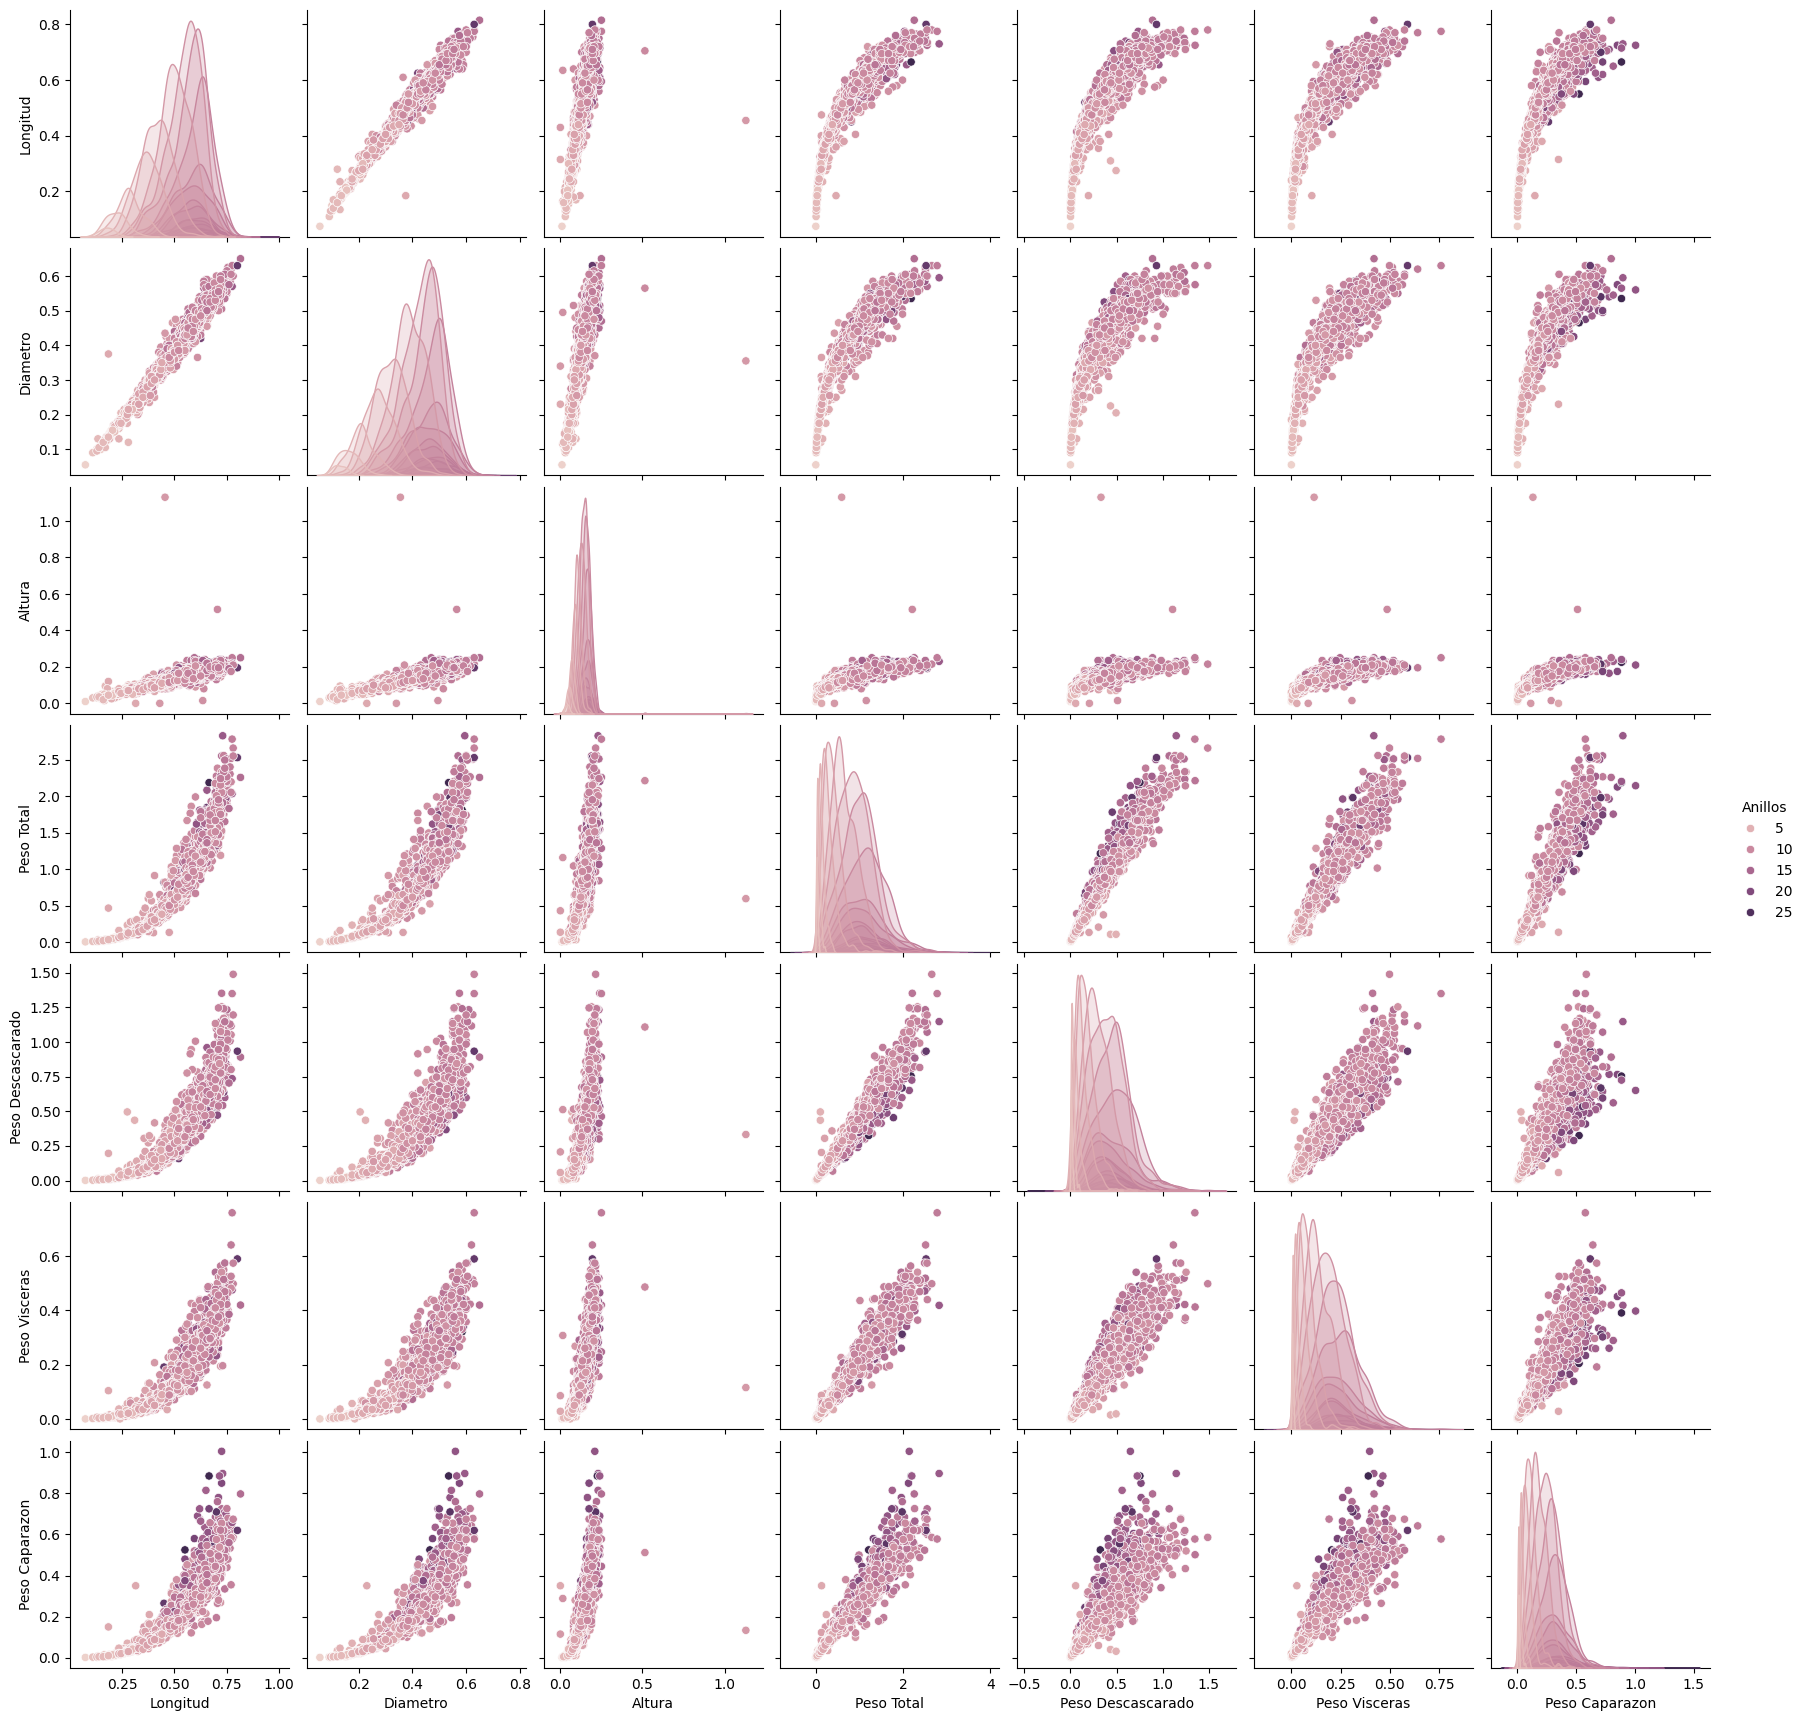

In [34]:
# Se grafica la relacion numerica de las variables, utilizando como parametro
# "Anillos", para buscar posibles relaciones lineales y outliers

sns.pairplot(df,hue='Anillos');

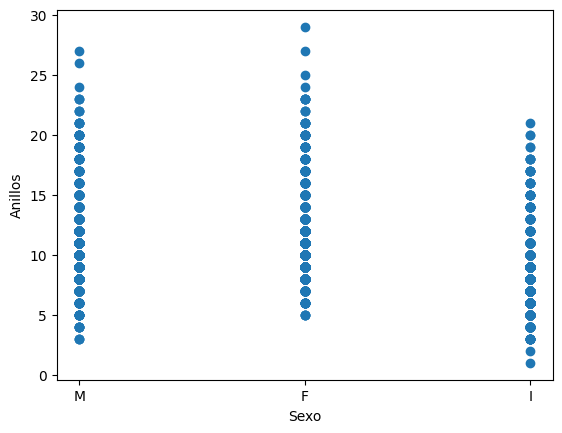

In [35]:
# Se grafica la relacion entre la variable categorica "Sexo" con la variable
# target "Anillos", para buscar alguna relacion existe entre ambas

plt.scatter(df['Sexo'], df['Anillos'])
plt.xlabel('Sexo')
plt.ylabel('Anillos')
plt.show()

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Otros pasos que crea conveniente para pre-procesar el dataset (mencione y explique)

Detalla las caracteristicas del dataset como nro de variables, nro de filas o instancias, si el problema es clasificacion binaria o multiclase, y otras características que crea conveniente.

Realice la división de datos (entrenamiento / testeo / CV según corresponda)

## Resolución:

El Dataset no contiene valores nulos, por lo tanto no se hara nada respecto de este tema

In [36]:
# Comprobacion de valores nulos

df.isnull().sum()

,0
Sexo,0
Longitud,0
Diametro,0
Altura,0
Peso Total,0
Peso Descascarado,0
Peso Visceras,0
Peso Caparazon,0
Anillos,0


Al obserevar la feature "Sexo" en el grafico comparativo con la cantidad de anillos, no pareciera que esta influya notoriamente a excepcion de los valores mas bajos o mas altos. Para el analisis, se va a eliminar dicha variable de momento, ya que no queda clara su influencia. Por lo tanto no habra variables categoricas.

In [37]:
# Se realiza una copia del DataFrame y se elimina la variable "Sexo"

df_copy = df.copy()
df_copy.drop('Sexo', axis=1, inplace=True)
df_copy.head()

,Longitud,Diametro,Altura,Peso Total,Peso Descascarado,Peso Visceras,Peso Caparazon,Anillos
0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
3,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
4,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8





## 4. **Clasificación con logistic regression**  
   

En este apartado entrenará un clasificador con la librería sklearn usando logistic regresion.

In [38]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Separate features (X) and target (y)
X = df_copy.drop('Anillos', axis=1)
y = df_copy['Anillos']

# Apply StandardScaler to the features
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame with scaled features, preserving column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display the head of the scaled DataFrame to verify
print('DataFrame con características escaladas (primeras 5 filas):\n')
display(X_scaled_df.head())

print('\nDimensiones del DataFrame escalado:\n')
print(X_scaled_df.shape)

# Now, split the scaled data into training and testing sets
from sklearn.model_selection import train_test_split
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

print('\nDimensiones de los conjuntos de entrenamiento y prueba (características escaladas):\n')
print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'X_test_scaled: {X_test_scaled.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

DataFrame con características escaladas (primeras 5 filas):



,Longitud,Diametro,Altura,Peso Total,Peso Descascarado,Peso Visceras,Peso Caparazon
0,-1.449007,-1.439892,-1.184252,-1.230344,-1.170967,-1.205327,-1.213054
1,0.049892,0.122015,-0.108247,-0.309601,-0.463610,-0.356844,-0.207277
2,-0.699558,-0.432210,-0.347360,-0.637928,-0.648334,-0.607739,-0.602404
3,-1.615552,-1.540661,-1.423364,-1.272150,-1.216022,-1.287438,-1.320816
4,-0.824466,-1.087204,-1.064696,-0.973393,-0.983991,-0.940746,-0.853848



Dimensiones del DataFrame escalado:

(4176, 7)

Dimensiones de los conjuntos de entrenamiento y prueba (características escaladas):

X_train_scaled: (2923, 7)
X_test_scaled: (1253, 7)
y_train: (2923,)
y_test: (1253,)


Antes de crear el modelo de regresion logistica, se le pidio a la IA que escale "df_copy" ya que es el dataframe que se utilizara para el modelo, no se hizo con el dataframe original ya que, como se menciono mas arriba, la variable "Sexo" no pareciera influir en el target.

### 4.1 Entrenamiento y evaluación

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression model trained successfully with scaled data.

Classification Report (Logistic Regression with Scaled Data):

              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         4
           4       0.42      0.42      0.42        19
           5       0.38      0.32      0.34        38
           6       0.30      0.18      0.23        87
           7       0.32      0.50      0.39       110
           8       0.33      0.36      0.34       177
           9       0.29      0.43      0.34       200
          10       0.22      0.31      0.26       191
          11       0.25      0.25      0.25       151
          12       0.00      0.00      0.00        74
          13       0.08      0.06      0.07        51
          14       0.00      0.00      0.00        35
          15       0.00      0.00      0.00        30
          16       0.00      0.00      0.00        18
      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,8,9,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,5,12,16,5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,2,8,16,47,12,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,2,8,55,29,11,3,2,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,5,26,64,63,16,3,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,3,15,47,86,34,15,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,2,14,18,64,60,29,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,2,7,12,41,48,38,...,0,0,0,0,0,0,0,0,0,0



Accuracy (Logistic Regression with Scaled Data): 0.2729


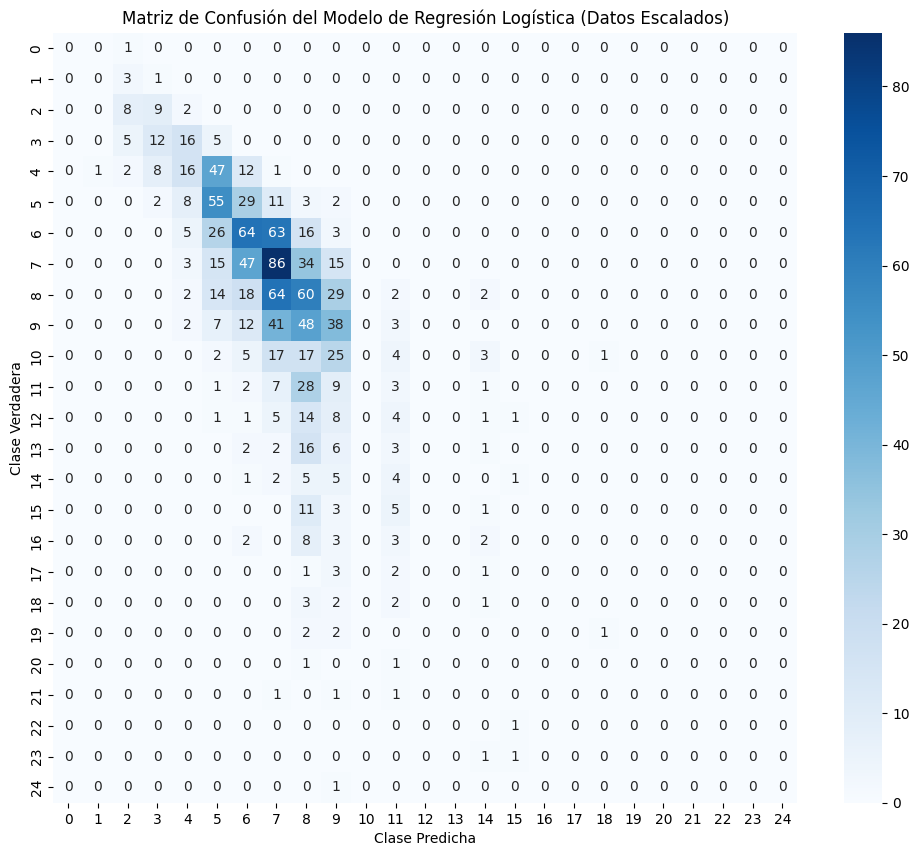

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Logistic Regression model using scaled data
# Increased max_iter for convergence, especially with multi-class classification
# Using 'multinomial' for multi-class classification and 'lbfgs' solver
model_lr_scaled = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
model_lr_scaled.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully with scaled data.\n")

# Make predictions on the scaled test set
y_pred_lr_scaled = model_lr_scaled.predict(X_test_scaled)

# Evaluate the model
print('Classification Report (Logistic Regression with Scaled Data):\n')
print(classification_report(y_test, y_pred_lr_scaled))

print('\nConfusion Matrix (Logistic Regression with Scaled Data):\n')
conf_matrix_scaled = confusion_matrix(y_test, y_pred_lr_scaled)
display(pd.DataFrame(conf_matrix_scaled))

accuracy_lr_scaled = accuracy_score(y_test, y_pred_lr_scaled)
print(f'\nAccuracy (Logistic Regression with Scaled Data): {accuracy_lr_scaled:.4f}')

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_scaled, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión del Modelo de Regresión Logística (Datos Escalados)')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.show()

### 4.2 Métricas de evaluación

Muestre el desempeño en el conjunto de datos de entrenamiento y testeo.
Mencione las métricas utilizadas. No se olvide de mostrar la matriz de confusión.
Explique los resultados obtenidos.

## 5- **Otro clasificador**

### 5.1 Elija otro modelo para entrenar un clasificador

Elija alguno de los modelos vistos: kNN, SVM o MLP para entrenar un clasificador usando los parámetros por defecto de sklearn.

Justifique su elección.

### 5.2 Entrenamiento del modelo.

### 5.3 Evaluación del desempeño

## 6  Tuneo de hiperparámetros

En esta sección debe modificar probar cómo la modificación de un hiperparámetro del modelo elegido en punto 5) afecta en los resultados.

Justifique y realice el experimento en esta sección.

## 6- Conclusiones

Fundamente, justifique con sus palabras.

# Referencias

Mencione los recursos utilizados

# BONUS 1

Si su dataset estaba relativamente balanceado, como bonus pruebe entrenar otro modelo clasificador diferente y comparar resultados con su clasificador elegido en 5) y el modelo elegido 6) luego del tuneo de hiperparámetros.



# BONUS 2

Si su dataset estaba desbalanceado, puebe utilizar alguna técnica para lidiar con el desbalance de clases durante el entrenamiento.

1) Ofrezca una comparativa de entrenar y evaluar modelos de Logistic regression con y sin class_weight='balanced' o el modelo SVC con y sin class_weight='balanced'

2) Pruebe entrenar KNN con y sin uso de SMOTE

( Ver apunte sobre Desbalance de clases de la cátedra )

